In [ ]:
# Dosya ve klasör işlemleri için (Resimleri bulmak için)
import os

# Verileri tablo halinde tutmak ve yönetmek için
import pandas as pd

# Matematiksel ve dizi işlemleri için
import numpy as np

# Eğitim sonuçlarını (grafikleri) görselleştirmek için
import matplotlib.pyplot as plt

# Derin öğrenme ve model kurma ana kütüphanesi
import tensorflow as tf
from tensorflow.keras import layers, models

# Cross-Validation (Çapraz Doğrulama) yapmak için veriyi bölmeye yarar
from sklearn.model_selection import StratifiedKFold

# Resimleri ön işlemeden geçirmek ve modele uygun hale getirmek için
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Her şeyin yolunda olduğunu kontrol etmek için bir çıktı alalım
print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!
TensorFlow Versiyonu: 2.21.0


In [ ]:
# 1. Dosya yolunu otomatik olarak 'şu anki klasör' yapıyoruz
# '.' işareti "bu dosyanın olduğu yer" demektir.
base_path = '.' 

classes = ['with_glasses', 'without_glasses']

data = []

print("--- Veri Tarama Başladı ---")

for label_name in classes:
    # Klasör yolunu oluşturuyoruz
    folder_path = os.path.join(base_path, label_name)
    
    # Etiket: with_glasses = 1, without_glasses = 0
    label = 1 if label_name == 'with_glasses' else 0
    
    if os.path.exists(folder_path):
        files = os.listdir(folder_path)
        # Sadece resim formatlarını (jpg, png, jpeg) filtreliyoruz
        valid_images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        print(f"Klasör: {label_name} -> {len(valid_images)} adet resim bulundu.")
        
        for img_name in valid_images:
            data.append({
                'filename': os.path.join(label_name, img_name), # Yol ve dosya adı
                'label': str(label) # Sayıyı metin yapıyoruz
            })
    else:
        print(f"Hata: '{label_name}' adlı bir klasör bulunamadı!")

# 2. Verileri bir tabloya (DataFrame) döküyoruz
df = pd.DataFrame(data)

# 3. Sonuçları Yazdırıyoruz
print("-" * 30)
if not df.empty:
    print(f"TOPLAM RESİM SAYISI: {len(df)}")
    print("\nSınıf Dağılımı:")
    # 1: Gözlüklü, 0: Gözlüksüz
    counts = df['label'].value_counts()
    if '1' in counts: print(f"Gözlüklü (1): {counts['1']} adet")
    if '0' in counts: print(f"Gözlüksüz (0): {counts['0']} adet")
else:
    print("Hiç resim bulunamadı.")

# Tablonun ilk 5 satırına bir bakalım
df.head()

--- Veri Tarama Başladı ---
Klasör: with_glasses -> 34121 adet resim bulundu.
Klasör: without_glasses -> 59483 adet resim bulundu.
------------------------------
TOPLAM RESİM SAYISI: 93604

Sınıf Dağılımı:
Gözlüklü (1): 34121 adet
Gözlüksüz (0): 59483 adet


,filename,label
0,with_glasses\face-10.jpg,1
1,with_glasses\face-100.jpg,1
2,with_glasses\face-1001.jpg,1
3,with_glasses\face-1002.jpg,1
4,with_glasses\face-1003.jpg,1


In [ ]:
# 1. Gözlüklü ve Gözlüksüzleri ayır
df_gozluklu = df[df['label'] == '1']
df_gozluksuz = df[df['label'] == '0']

# 2. Gözlüksüzlerden ve Gözlüklülerden 10 biner adet rastgele örnek alıyoruz
df_gozluklu = df[df['label'] == '1'].sample(n=10000, random_state=42)
df_gozluksuz = df[df['label'] == '0'].sample(n=10000, random_state=42)

df_final = pd.concat([df_gozluklu, df_gozluksuz], axis=0)

# 3. Veriyi karıştırıyoruz (Model hep önce gözlüklüleri sonra gözlüksüzleri görmesin)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Sonuçları yazdırıyoruz
print("--- Veri Dengeleme Tamamlandı ---")
print(f"Yeni Toplam Resim Sayısı: {len(df_final)}")
print(f"Gözlüklü Sayısı: {len(df_final[df_final['label'] == '1'])}")
print(f"Gözlüksüz Sayısı: {len(df_final[df_final['label'] == '0'])}")

# Tabloya tekrar bir bakalım
df_final.head()

--- Veri Dengeleme Tamamlandı ---
Yeni Toplam Resim Sayısı: 20000
Gözlüklü Sayısı: 10000
Gözlüksüz Sayısı: 10000


,filename,label
0,without_glasses\flickr_faces__noglasses__31291...,0
1,with_glasses\glasses_dataset1__sunglasses-imag...,1
2,with_glasses\imgalignceleba__withglasses__0660...,1
3,with_glasses\flickr_faces__readingglasses__561...,1
4,without_glasses\flickr_faces__noglasses__36043...,0


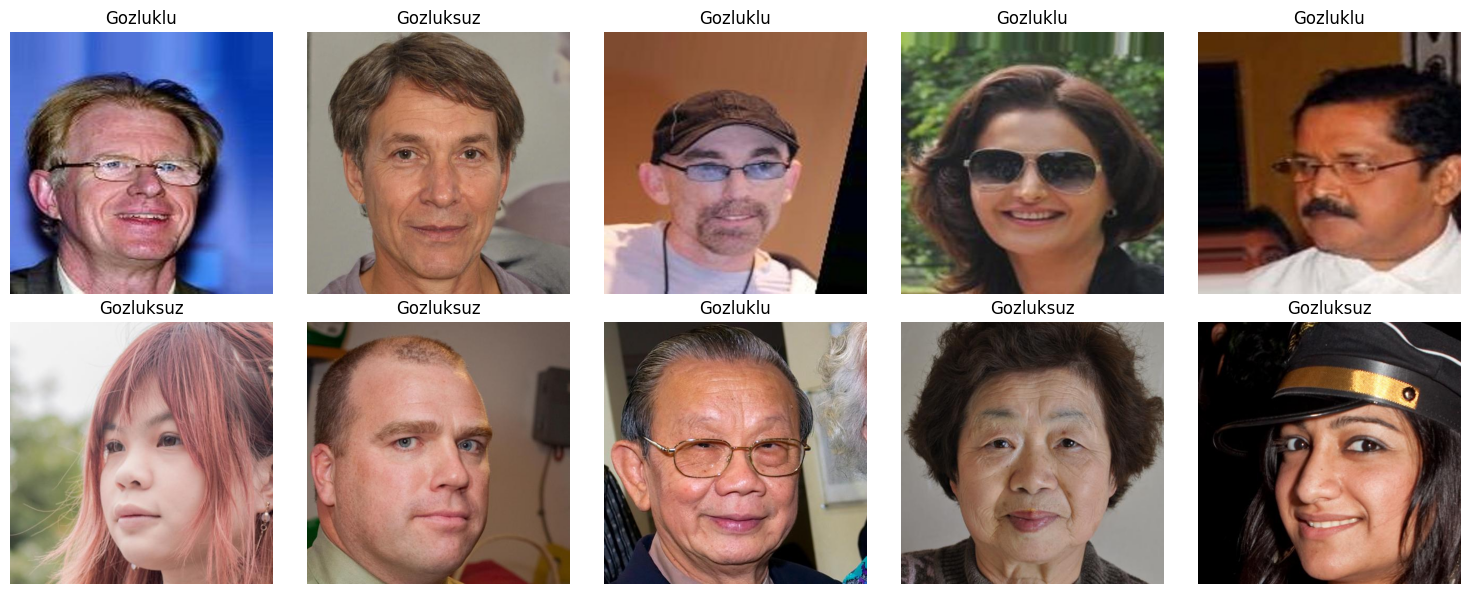

In [ ]:
import cv2

# Rastgele 10 örnek seçelim
sample_df = df_final.sample(10)

plt.figure(figsize=(15, 6))

for i, (index, row) in enumerate(sample_df.iterrows()):
    plt.subplot(2, 5, i + 1)
    
    # Resmi okuyoruz
    img = cv2.imread(row['filename'])
    # OpenCV BGR okur, Matplotlib RGB bekler; o yüzden çeviriyoruz
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    label_text = "Gozluklu" if row['label'] == '1' else "Gozluksuz"
    plt.title(label_text)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

print("10-Fold için profesyonel metrikli model hazır kanka!")

10-Fold için profesyonel metrikli model hazır kanka!


In [ ]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# AYARLAR 
IMG_SIZE = (128, 128)
BATCH_SIZE = 64
NUM_FOLDS = 5  
EPOCHS = 10     # Erken durdurma sayesinde her fold 10 tur sürmeyebilir

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
datagen = ImageDataGenerator(rescale=1./255)

fold_no = 1
fold_results = [] # Tüm metrikleri burada saklayacağız

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# 5-Fold Döngüsü Başlıyor
for train_index, val_index in skf.split(df_final['filename'], df_final['label']):
    print(f"\n>>>> FOLD {fold_no} / {NUM_FOLDS} EĞİTİLİYOR <<<<")
    
    train_df = df_final.iloc[train_index]
    val_df = df_final.iloc[val_index]
    
    train_gen = datagen.flow_from_dataframe(
        train_df, x_col='filename', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
    )
    
    val_gen = datagen.flow_from_dataframe(
        val_df, x_col='filename', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
    )
    
    model = build_model()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Bu Fold'un son değerlerini alalım
    val_metrics = model.evaluate(val_gen, verbose=0)
    # val_metrics sırası: [loss, accuracy, precision, recall]
    acc = val_metrics[1]
    prec = val_metrics[2]
    rec = val_metrics[3]
    f1 = 2 * (prec * rec) / (prec + rec + 1e-7) # F1 Score Hesabı
    
    fold_results.append({
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    })
    
    print(f"Fold {fold_no} Bitti -> Acc: %{acc*100:.2f}, F1: {f1:.4f}")
    
    # Şampiyonu seçme (En yüksek Accuracy'e göre kaydediyoruz)
    if fold_no == 1 or acc > max([x['accuracy'] for x in fold_results[:-1]]):
        model.save('gozluk_tespit_modeli_final.h5')
        print(">>> Yeni Şampiyon Model Kaydedildi! <<<")
        
    fold_no += 1

# FİNAL RAPORU
print("\n" + "="*40)
print("5-FOLD ÇAPRAZ DOĞRULAMA SONUÇLARI")
avg_acc = np.mean([x['accuracy'] for x in fold_results])
avg_f1 = np.mean([x['f1_score'] for x in fold_results])
print(f"Ortalama Doğruluk (Accuracy): %{avg_acc*100:.2f}")
print(f"Ortalama F1-Score: {avg_f1:.4f}")
print("="*40)


>>>> FOLD 1 / 5 EĞİTİLİYOR <<<<
Found 16000 validated image filenames belonging to 2 classes.
Found 4000 validated image filenames belonging to 2 classes.
Epoch 1/10


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 124s 492ms/step - accuracy: 0.9254 - loss: 0.1708 - precision: 0.9215 - recall: 0.9301 - val_accuracy: 0.9875 - val_loss: 0.0377 - val_precision: 0.9924 - val_recall: 0.9825
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 128s 512ms/step - accuracy: 0.9862 - loss: 0.0452 - precision: 0.9873 - recall: 0.9851 - val_accuracy: 0.9898 - val_loss: 0.0366 - val_precision: 0.9975 - val_recall: 0.9820
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 514ms/step - accuracy: 0.9899 - loss: 0.0348 - precision: 0.9898 - recall: 0.9900 - val_accuracy: 0.9925 - val_loss: 0.0264 - val_precision: 0.9955 - val_recall: 0.9895
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 127s 507ms/step - accuracy: 0.9926 - loss: 0.0245 - precision: 0.9924 - recall: 0.9927 - val_accuracy: 0.9910 - val_loss: 0.0259 - val_precision: 0.9965 - val_recall: 0.9855
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 516ms/step - accuracy: 0.9939 - loss: 0.0192 - precision: 0.9940 - recall: 0.9939 - val_accuracy: 0.9948 - val

Fold 1 Bitti -> Acc: %99.10, F1: 0.9910
>>> Yeni Şampiyon Model Kaydedildi! <<<

>>>> FOLD 2 / 5 EĞİTİLİYOR <<<<
Found 16000 validated image filenames belonging to 2 classes.
Found 4000 validated image filenames belonging to 2 classes.


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 131s 510ms/step - accuracy: 0.9271 - loss: 0.1660 - precision: 0.9220 - recall: 0.9333 - val_accuracy: 0.9858 - val_loss: 0.0487 - val_precision: 0.9802 - val_recall: 0.9915
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 127s 506ms/step - accuracy: 0.9867 - loss: 0.0437 - precision: 0.9887 - recall: 0.9846 - val_accuracy: 0.9880 - val_loss: 0.0413 - val_precision: 0.9929 - val_recall: 0.9830
Fold 3 Bitti -> Acc: %98.58, F1: 0.9858

>>>> FOLD 4 / 5 EĞİTİLİYOR <<<<
Found 16000 validated image filenames belonging to 2 classes.
Found 4000 validated image filenames belonging to 2 classes.


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 131s 513ms/step - accuracy: 0.9061 - loss: 0.2157 - precision: 0.9057 - recall: 0.9066 - val_accuracy: 0.9812 - val_loss: 0.0507 - val_precision: 0.9844 - val_recall: 0.9780
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 127s 509ms/step - accuracy: 0.9827 - loss: 0.0617 - precision: 0.9836 - recall: 0.9819 - val_accuracy: 0.9890 - val_loss: 0.0383 - val_precision: 0.9885 - val_recall: 0.9895
Fold 4 Bitti -> Acc: %98.12, F1: 0.9812

>>>> FOLD 5 / 5 EĞİTİLİYOR <<<<
Found 16000 validated image filenames belonging to 2 classes.
Found 4000 validated image filenames belonging to 2 classes.


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 129s 505ms/step - accuracy: 0.9071 - loss: 0.2075 - precision: 0.8967 - recall: 0.9201 - val_accuracy: 0.9843 - val_loss: 0.0541 - val_precision: 0.9806 - val_recall: 0.9880
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 127s 507ms/step - accuracy: 0.9824 - loss: 0.0584 - precision: 0.9855 - recall: 0.9793 - val_accuracy: 0.9880 - val_loss: 0.0413 - val_precision: 0.9919 - val_recall: 0.9840
Fold 5 Bitti -> Acc: %98.43, F1: 0.9843

10-FOLD ÇAPRAZ DOĞRULAMA SONUÇLARI
Ortalama Doğruluk (Accuracy): %98.40
Ortalama F1-Score: 0.9841


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step


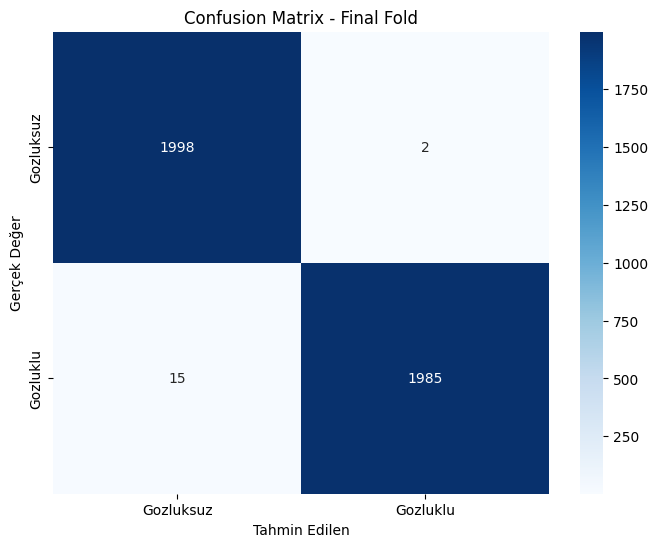

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.models import load_model

# 1. Şampiyon modeli dosyadan yükle
best_model = load_model('gozluk_tespit_modeli_final.h5')

# 2. Son fold'un doğrulama verilerini (val_gen) kullanarak matrisi çıkar
val_gen.reset()
predictions = best_model.predict(val_gen)
y_pred = (predictions > 0.5).astype(int)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Gozluksuz', 'Gozluklu'], yticklabels=['Gozluksuz', 'Gozluklu'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Confusion Matrix - Final Fold')
plt.show()